In [ ]:
!pip install ultralytics roboflow
from ultralytics import YOLO
import os

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="KT4RaizFZxAELT1tVIcZ")
project = rf.workspace("prathams-workspace-pv0wn").project("atm-rzmpy-edc9m")
version = project.version(5)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to ATM-5 in yolov8:: 100%|██████████| 3633/3633 [00:00<00:00, 8887.70it/s]


In [ ]:
# Initialize a YOLOv8n model for training. This will download the weights if not already present.
model = YOLO('yolov8n.pt')

In [ ]:
model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=150,
    patience=50,
    degrees=10.0,    # Rotate images slightly
    shear=2.0,      # Distort images slightly
    perspective=0.0001,
    flipud=0.5,      # Flip vertically (useful if camera angles vary)
    name='atm_detection_run' # Specify a custom name for the training run's output directory
)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ATM-5/data.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=atm_detection_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pati

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7dc2bfc90ad0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
from ultralytics import YOLO

# Load the best model from the specified training run
model = YOLO('/content/runs/detect/atm_detection_run/weights/best.pt')

# Run validation on the test set
metrics = model.val()

# Print specific precision, recall, and mAP results
print(f"Precision (P): {metrics.results_dict['metrics/precision(B)'] * 100:.2f}%")
print(f"Recall (R): {metrics.results_dict['metrics/recall(B)'] * 100:.2f}%")
print(f"mAP50: {metrics.results_dict['metrics/mAP50(B)'] * 100:.2f}%")
print(f"mAP50-95: {metrics.results_dict['metrics/mAP50-95(B)'] * 100:.2f}%")

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 932.8±435.9 MB/s, size: 26.6 KB)
val: Scanning /content/ATM-5/valid/labels.cache... 151 images, 47 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 151/151 57.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.5it/s 4.1s
                   all        151        148      0.411      0.524      0.341       0.17
                   ATM         80        122      0.433      0.394      0.331      0.158
       person near ATM         25         26       0.39      0.654      0.351      0.181
Speed: 5.3ms preprocess, 6.4ms inference, 0.0ms loss, 4.1ms postprocess per image
Results saved to /content/runs/detect/val
Precision (P): 41.15%
Recall (R): 52.38%
mAP50: 34.09%
mAP50-95: 16.97%


In [ ]:
import os

print("Searching for best.pt in /content/runs...")
found_file = False
for root, dirs, files in os.walk("/content/runs"):
    for file in files:
        if file == "best.pt":
            print(os.path.join(root, file))
            found_file = True
if not found_file:
    print("No 'best.pt' file found in /content/runs.")

Searching for best.pt in /content/runs...
/content/runs/detect/atm_detection_run/weights/best.pt


Showing results from: /content/runs/detect/val
Graph results.png was not generated yet.

--- confusion_matrix.png ---


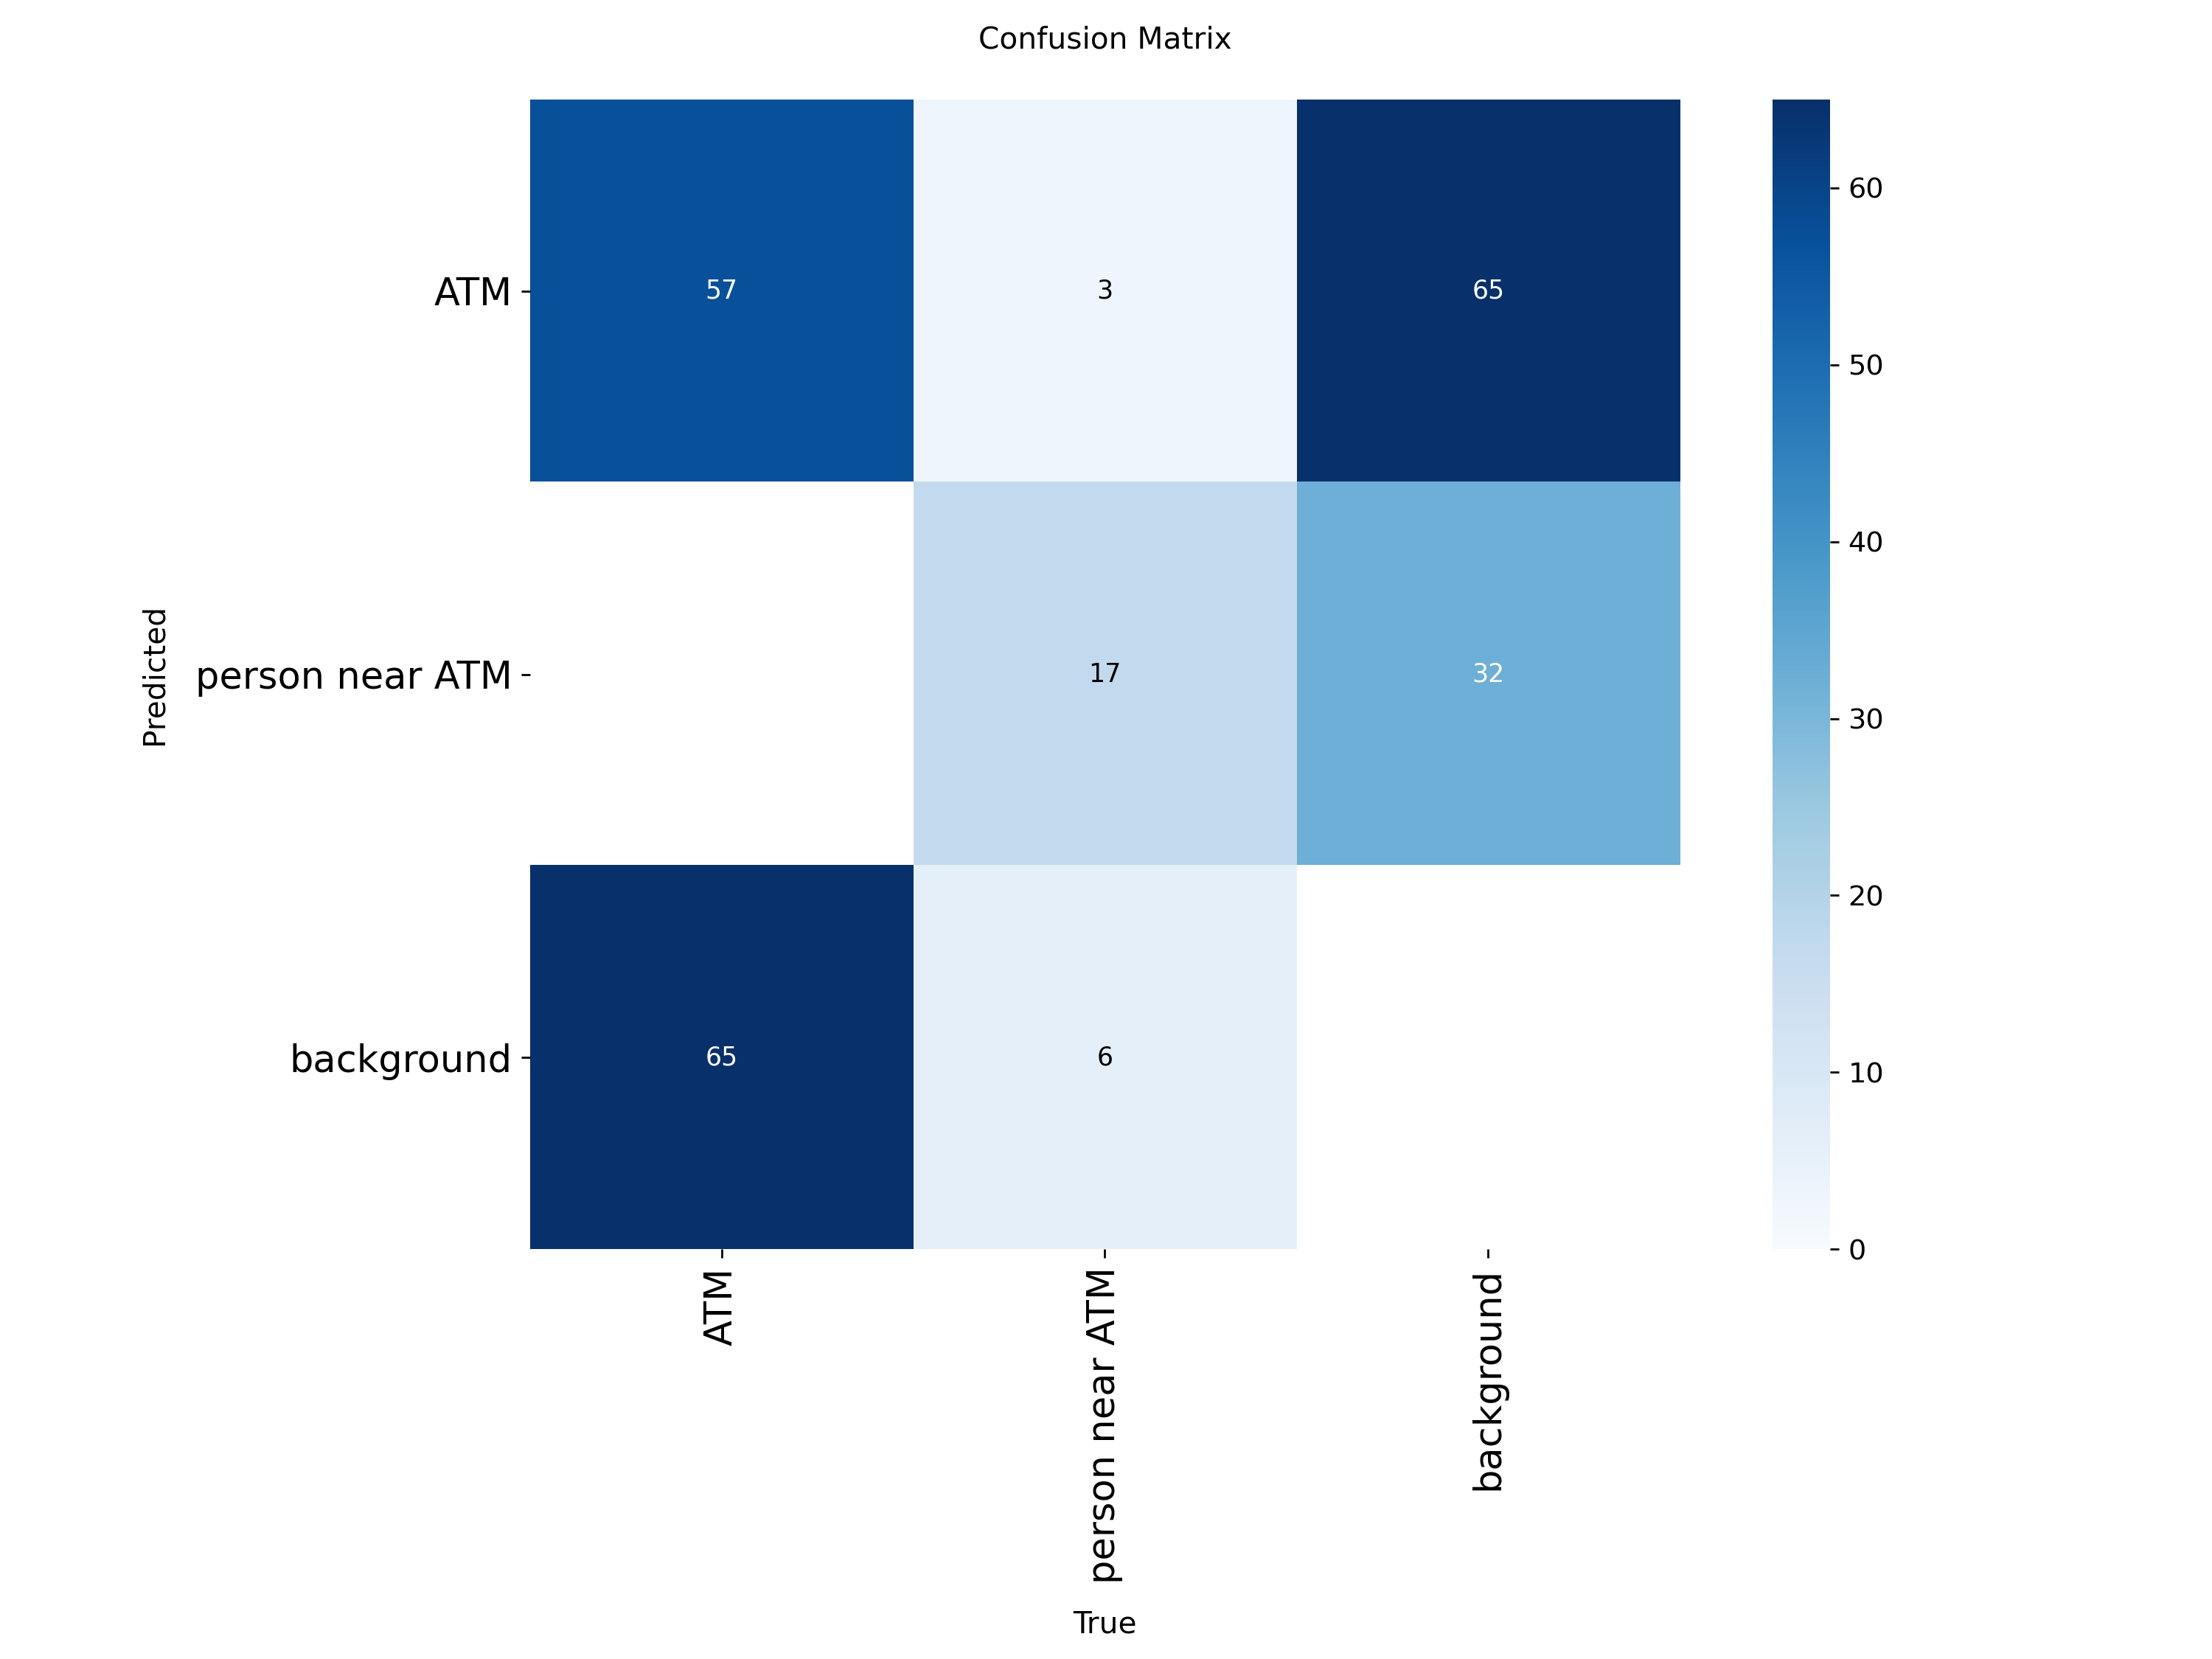

Graph PR_curve.png was not generated yet.
Graph F1_curve.png was not generated yet.
